In [411]:
import importlib
import ToFPipeline
import pandas as pd
importlib.reload(ToFPipeline)

<module 'ToFPipeline' from 'c:\\Users\\mogilows\\Documents\\PolScope\\ToFPipeline.py'>

In [412]:
importlib.reload(ToFPipeline)
ToFPipeline.GlobalConfig.load("config.yaml")
runNo=1999

In [413]:
data = ToFPipeline.NXSLoader("data").load(runNumbers=[runNo]).defaultPreprocessing(baselineRegion=[1800,1850])

Random trainId: 1999, pulseId: 0


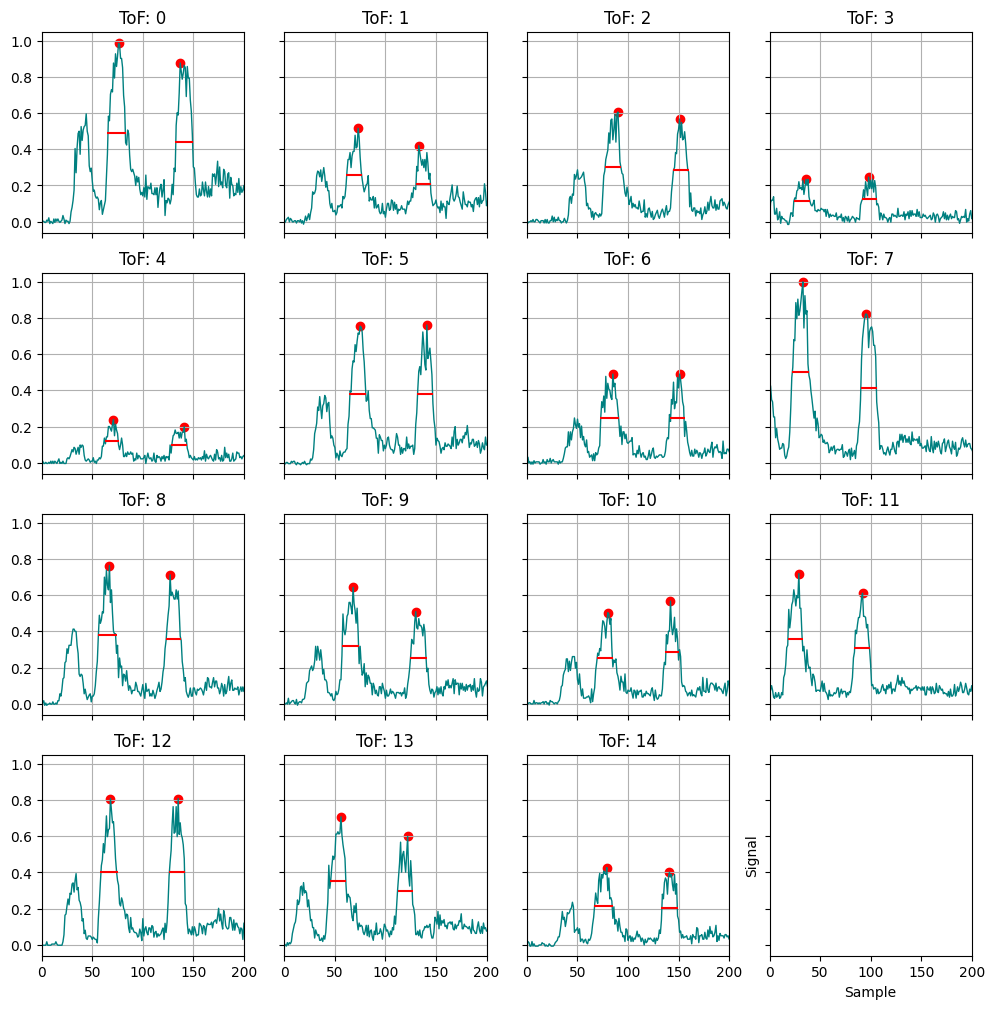

In [414]:
results = ToFPipeline.PeakFinder(data.data).stack().normalize().process(threshold=0.01,peakNo=1,roi=[0,200],minWidth=False,symmetric=False).dataframe().plot(logScale=False,xmin=0,xmax=200)

In [415]:
ToFPipeline.AuxFunc(results.results).addData(data.angles, key="Angles", axis="detector")
import pandas as pd
setPhotonEnergy = [1300]
runs = runNo
setEnergyRun = {"daq_run": runs, "Photon Energy": setPhotonEnergy}
runsPhotonEnergy = pd.DataFrame(setEnergyRun)
merge = pd.merge(data.data["trainId"].to_dataframe(),runsPhotonEnergy, on="daq_run", how="left")
merge=merge[merge["pulseId"]==0]
trim=merge[["trainId","daq_run","Photon Energy"]]
trim = trim.loc[:,~trim.columns.duplicated()]
ToFPipeline.AuxFunc(results.results).addData(trim)


In [416]:
#ToFPipeline.GlobalConfig.load("config.yaml")
#importlib.reload(ToFPipeline)

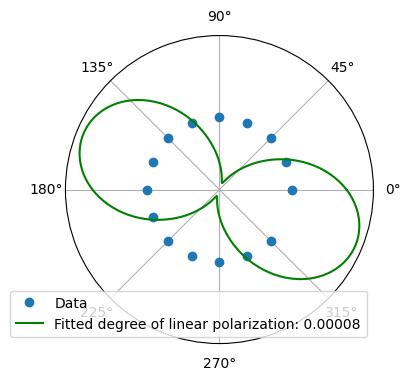

(array([ 7.54148808e-05, -3.87913935e-01,  7.91008943e-02]),
 array([[ 4.73946515e-10, -4.07036821e-09,  2.49792866e-12],
        [-4.07036821e-09,  1.80556188e-02, -1.59726102e-10],
        [ 2.49792866e-12, -1.59726102e-10,  1.38391224e-12]]))

In [417]:
beta=2
calib = ToFPipeline.Calibrate(results.results).transmission(peakNo=1,setBeta=beta,setPlin=0,setPhi=0).transmissionParam
ToFPipeline.Plotter(results.results).plotPol(calib,peakNo=1,beta=beta)

In [418]:
#importlib.reload(ToFPipeline)
#ToFPipeline.GlobalConfig.load("config.yaml")

Random trainId: 2119, pulseId: 0


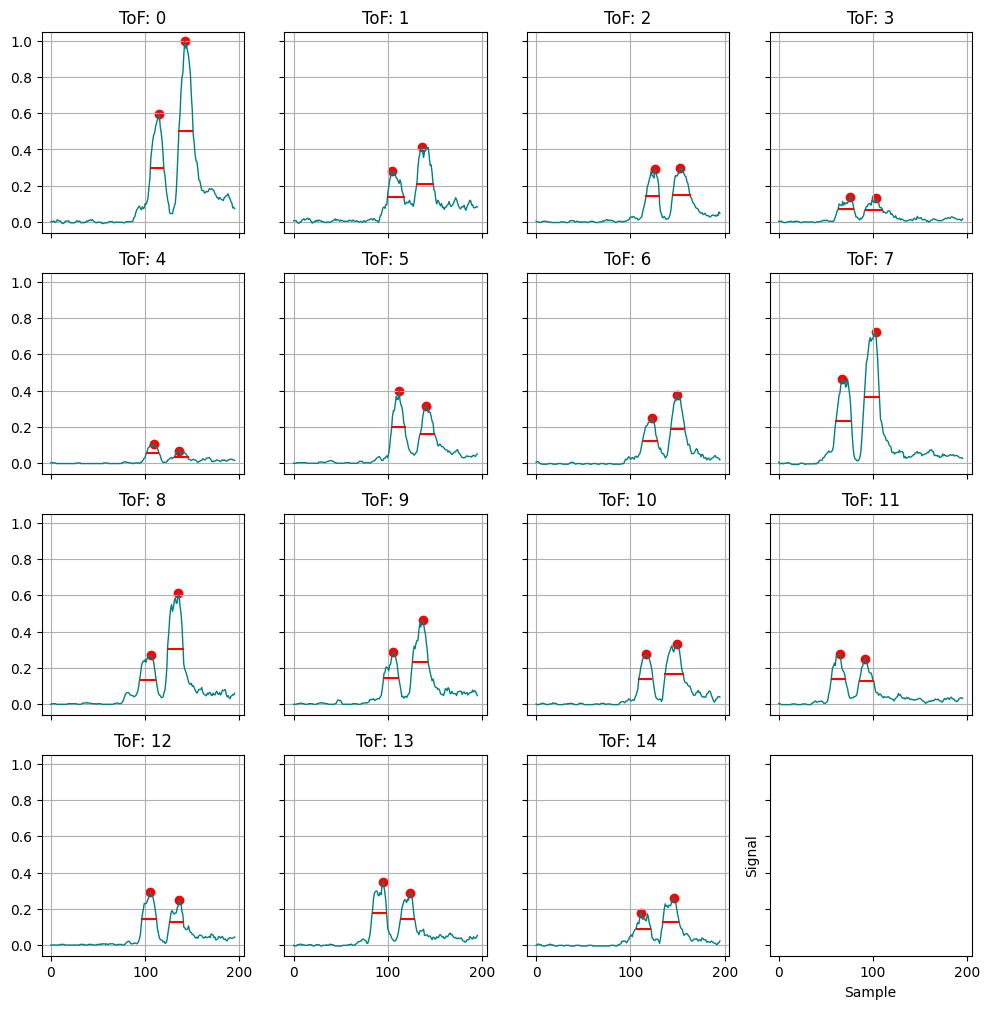

In [419]:
data = ToFPipeline.NXSLoader("data").load(runNumbers=[2119],roi=[200,400]).defaultPreprocessing(baselineRegion=[0,10])
results = ToFPipeline.PeakFinder(data.data).stack().smooth(windowSize=5).normalize().process(threshold=0.01,peakNo=1,roi=[None,400],minWidth=False,symmetric=False).dataframe().plot(logScale=False,xmin=None,xmax=None)

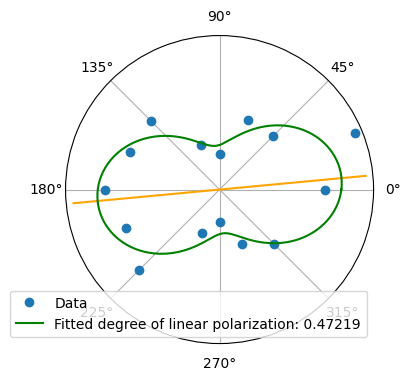

Completed run 2119


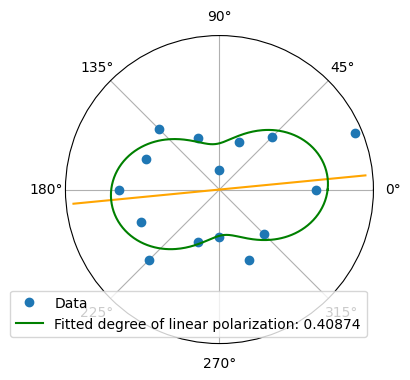

Completed run 2120


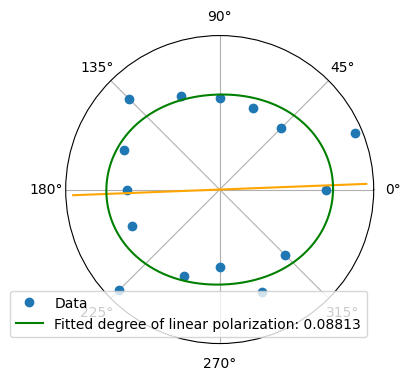

Completed run 2121


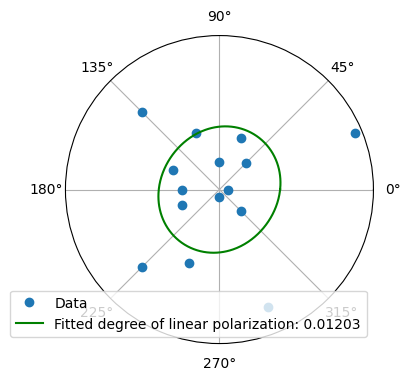

Completed run 2122


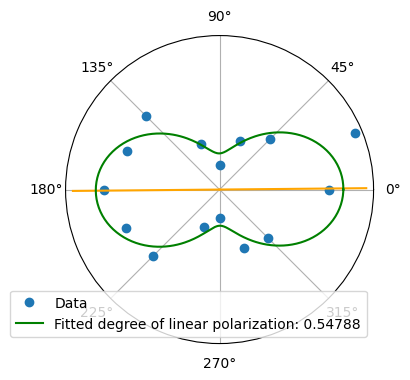

Completed run 2123


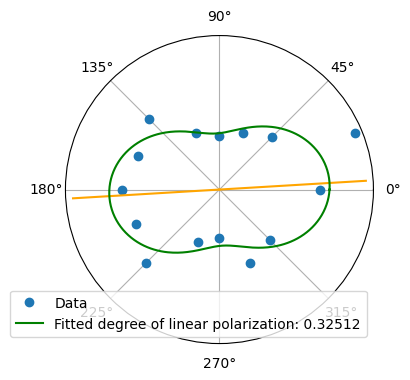

Completed run 2124


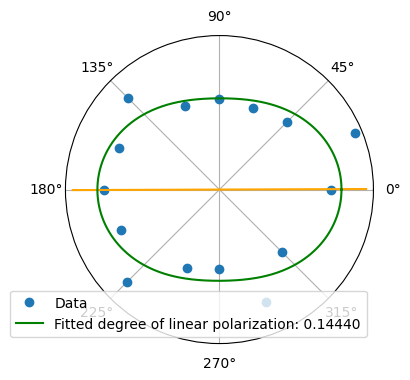

Completed run 2125


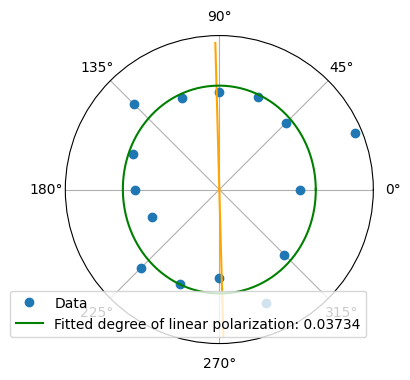

Completed run 2126


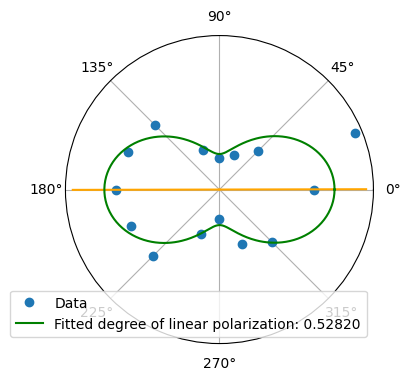

Completed run 2127


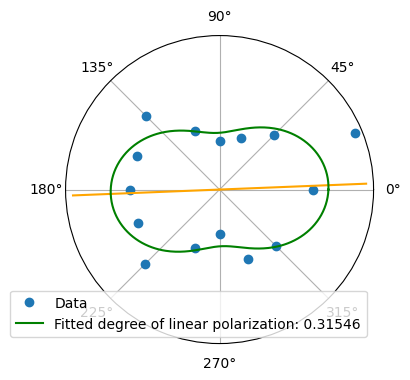

Completed run 2128


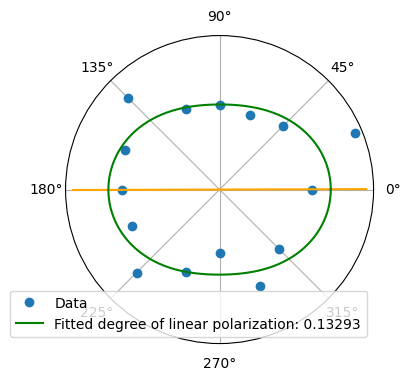

Completed run 2129


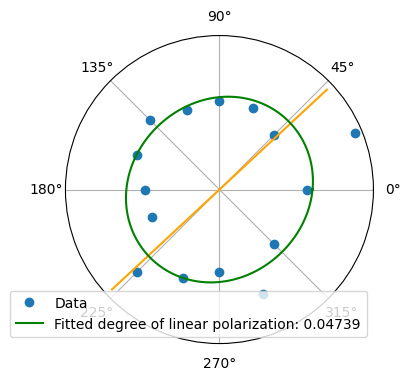

Completed run 2130


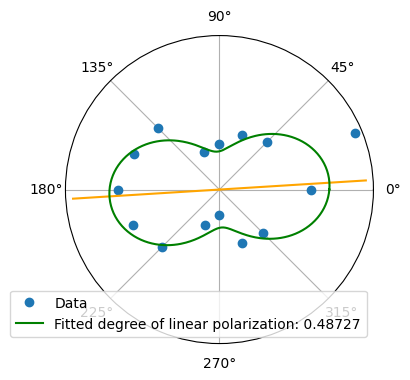

Completed run 2131


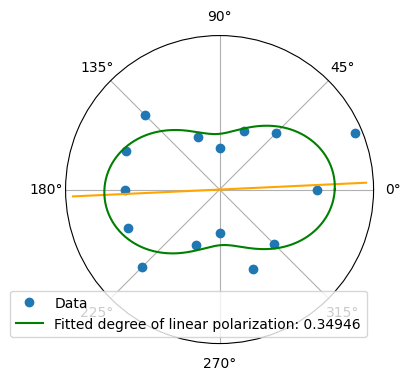

Completed run 2132


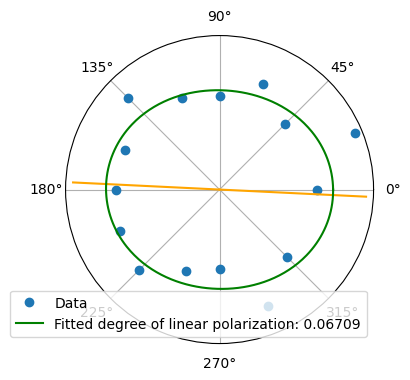

Completed run 2133


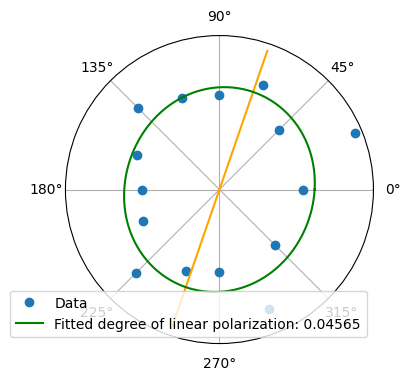

Completed run 2134


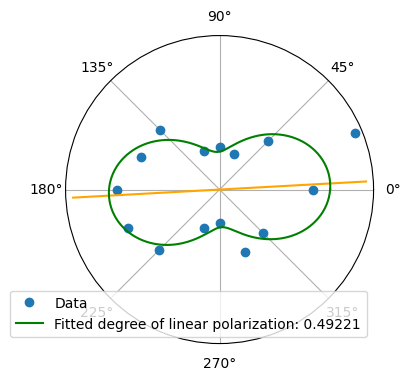

Completed run 2135


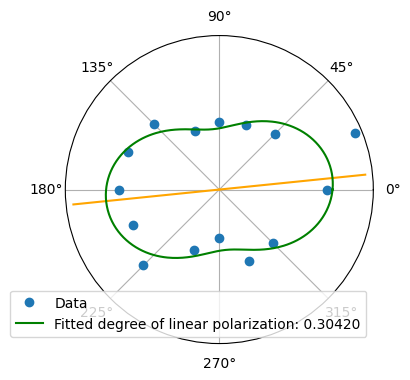

Completed run 2136


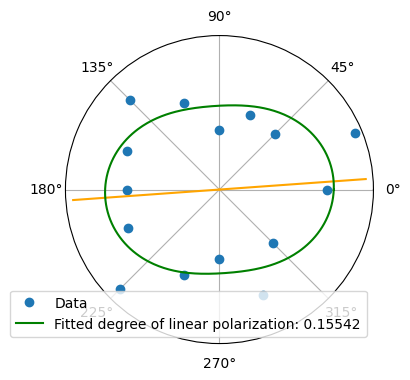

Completed run 2137


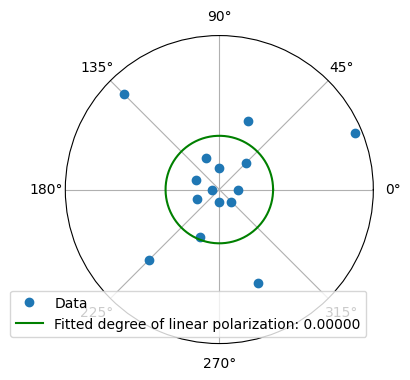

Completed run 2138


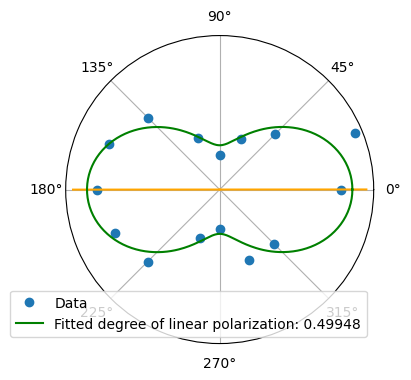

Completed run 2139


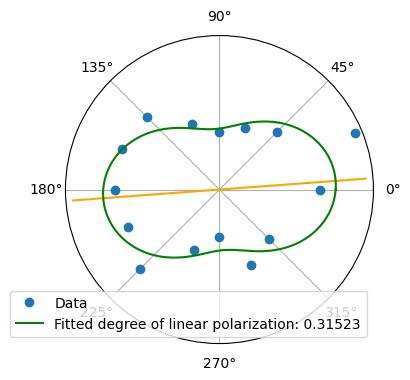

Completed run 2140


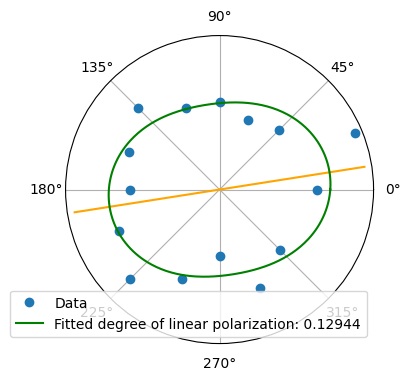

Completed run 2141


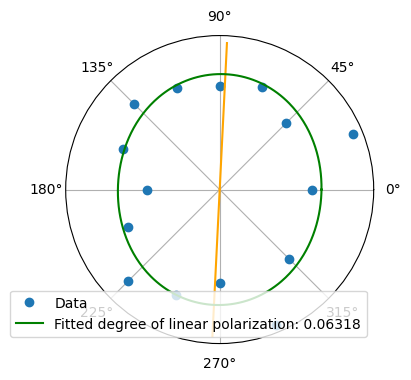

Completed run 2142


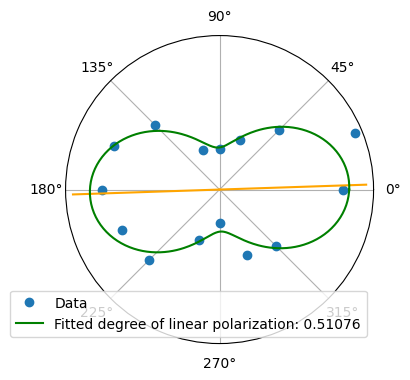

Completed run 2143


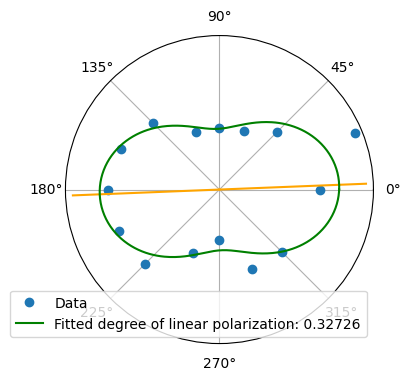

Completed run 2144


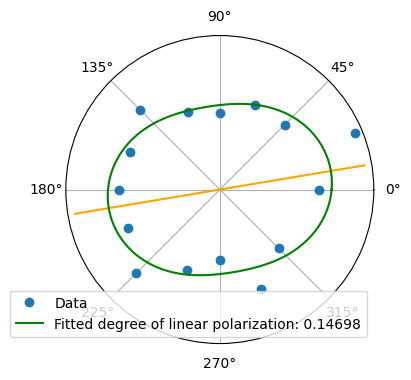

Completed run 2145


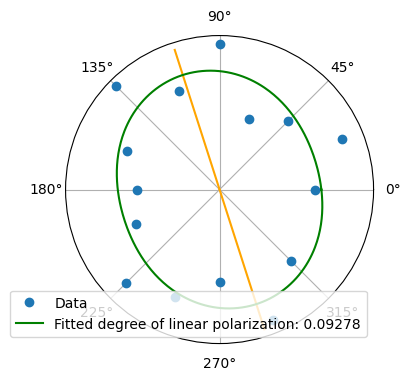

Completed run 2146


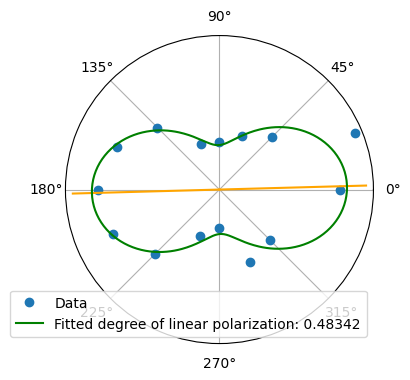

Completed run 2147


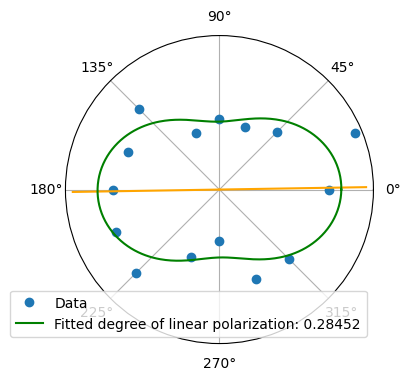

Completed run 2148


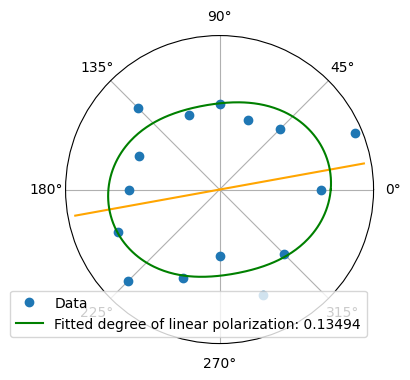

Completed run 2149


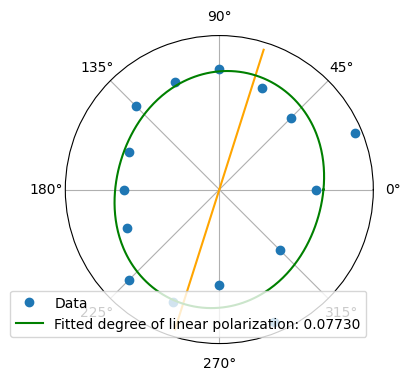

Completed run 2150


In [420]:
values=[]
energies=[]
daq_run=[]
for i in range(32):
    runNo = 2119+i
    data = ToFPipeline.NXSLoader("data").load(runNumbers=[runNo],roi=[200,400]).defaultPreprocessing(baselineRegion=[0,10],ToF=list(range(15)))
    results = ToFPipeline.PeakFinder(data.data).stack().smooth(windowSize=5).normalize().process(threshold=0.01,peakNo=1,roi=[None,400],minWidth=False,symmetric=False).dataframe()#.plot(logScale=False,xmin=None,xmax=None)
    ToFPipeline.AuxFunc(results.results).addData(data.angles, key="Angles", axis="detector")
    setPhotonEnergy = [1300-i//4*10]
    runs = runNo
    setEnergyRun = {"daq_run": runs, "Photon Energy": setPhotonEnergy}
    runsPhotonEnergy = pd.DataFrame(setEnergyRun)
    merge = pd.merge(data.data["trainId"].to_dataframe(),runsPhotonEnergy, on="daq_run", how="left")
    merge=merge[merge["pulseId"]==0]
    trim=merge[["trainId","daq_run","Photon Energy"]]
    trim = trim.loc[:,~trim.columns.duplicated()]
    ToFPipeline.AuxFunc(results.results).addData(trim)
    popt,pcov = ToFPipeline.Plotter(results.results).plotPol(calib,peakNo=1,beta=2)
    values.append(popt)
    energies.append(setPhotonEnergy[0])
    daq_run.append(runNo)
    print(f"Completed run {runNo}")
values=pd.DataFrame(values, columns=["PLin","phi","scale"])
values["Photon Energy"]=energies
values["daq_run"]=daq_run


In [421]:
raw = """
> |Photon Energy|daq_run|Ugap|Ushift
> |1300|2119|29.673|14
> |1300|2120|28.224|17
> |1300|2121|26.669|20
> |1300|2122|25.169|23
> |1290|2123|29.575|14
> |1290|2124|28.13|17
> |1290|2125|26.579|20
> |1290|2126|25.083|23
> |1280|2127|29.478|14
> |1280|2128|28.034|17
> |1280|2129|26.489|20
> |1280|2130|24.999|23
> |1270|2131|29.378|14
> |1270|2132|27.938|17
> |1270|2133|26.399|20
> |1270|2134|24.913|23
> |1260|2135|29.28|14
> |1260|2136|27.843|17
> |1260|2137|26.308|20
> |1260|2138|24.827|23
> |1250|2139|29.179|14
> |1250|2140|27.747|17
> |1250|2141|26.216|20
> |1250|2142|24.741|23
> |1240|2143|29.079|14
> |1240|2144|27.649|17
> |1240|2145|26.124|20
> |1240|2146|24.655|23
> |1230|2147|28.979|14
> |1230|2148|27.552|17
> |1230|2149|26.03|20
> |1230|2150|24.567|23
> |1230|2152|28.979|14
> |1230|2153|27.552|17
> |1230|2154|26.03|20
> |1230|2155|24.567|23
> |1220|2156|28.878|14
> |1220|2157|27.454|17
> |1220|2158|25.938|20
> |1220|2159|24.479|23
> |1210|2160|28.776|14
> |1210|2161|27.356|17
> |1210|2162|25.845|20
> |1210|2163|24.392|23
> |1200|2164|28.673|14
> |1200|2165|27.257|17
> |1200|2166|25.751|20
> |1200|2167|24.304|23
> |1190|2168|28.569|14
> |1190|2169|27.157|17
> |1190|2170|25.655|20
> |1190|2171|24.216|23
> |1180|2172|28.466|14
> |1180|2173|27.058|17
> |1180|2174|25.56|20
> |1180|2175|24.126|23
> |1170|2176|28.362|14
> |1170|2177|26.956|17
> |1170|2178|25.464|20
> |1170|2179|24.036|23
> |1160|2180|28.257|14
> |1160|2181|26.854|17
> |1160|2182|25.368|20
> |1160|2183|23.946|23
> |1150|2184|28.151|14
> |1150|2185|26.753|17
> |1150|2186|25.271|20
> |1150|2187|23.854|23
> |1140|2188|28.046|14
> |1140|2189|26.651|17
> |1140|2190|25.175|20
> |1140|2191|23.763|23
> |1130|2192|27.938|14
> |1130|2193|26.548|17
> |1130|2194|25.075|20
> |1130|2195|23.671|23
> |1120|2196|27.831|14
> |1120|2197|26.444|17
> |1120|2198|24.978|20
> |1120|2199|23.579|23
> |1110|2200|27.722|14
> |1110|2201|26.341|17
> |1110|2202|24.878|20
> |1110|2203|23.485|23
> |1100|2204|27.614|14
> |1100|2205|26.235|17
> |1100|2206|24.778|20
> |1100|2207|23.392|23
> |1090|2208|27.503|14
> |1090|2209|26.13|17
> |1090|2210|24.679|20
> |1090|2211|23.298|23
> |1080|2212|27.394|14
> |1080|2213|26.022|17
> |1080|2214|24.577|20
> |1080|2215|23.204|23
> |1070|2216|27.282|14
> |1070|2217|25.915|17
> |1070|2218|24.476|20
> |1070|2219|23.108|23
> |1060|2220|27.171|14
> |1060|2221|25.808|17
> |1060|2222|24.374|20
> |1060|2223|23.013|23
> |1050|2224|27.058|14
> |1050|2225|25.7|17
> |1050|2226|24.271|20
> |1050|2227|22.915|23
> |1040|2228|26.944|14
> |1040|2229|25.591|17
> |1040|2230|24.167|20
> |1040|2231|22.819|23
> |1030|2232|26.829|14
> |1030|2233|25.479|17
> |1030|2234|24.062|20
> |1030|2235|22.72|23
> |1020|2236|26.714|14
> |1020|2237|25.37|17
> |1020|2238|23.958|20
> |1020|2239|22.622|23
> |1010|2240|26.599|14
> |1010|2241|25.257|17
> |1010|2242|23.851|20
> |1010|2243|22.522|23
> |1000|2244|26.481|14
> |1000|2245|25.146|17
> |1000|2246|23.745|20
> |1000|2247|22.423|23
"""

In [422]:
import pandas as pd
from io import StringIO
rawdf = pd.read_csv(StringIO(raw), sep="|", skiprows=1).dropna().astype({"Photon Energy":int,"daq_run":int,"Ugap":float,"Ushift":float})
runTable = rawdf[["daq_run","Ugap","Ushift"]]
complete = values.merge(runTable, on="daq_run")

complete

,PLin,phi,scale,Photon Energy,daq_run,Ugap,Ushift
0,4.721940e-01,0.093361,0.062248,1300,2119,29.673,14.0
1,4.087362e-01,0.096741,0.063089,1300,2120,28.224,17.0
2,8.813482e-02,0.038680,0.077405,1300,2121,26.669,20.0
3,1.202686e-02,0.951197,0.094291,1300,2122,25.169,23.0
4,5.478781e-01,0.009392,0.057946,1290,2123,29.575,14.0
5,3.251166e-01,0.059784,0.065167,1290,2124,28.130,17.0
6,1.443963e-01,0.003599,0.075687,1290,2125,26.579,20.0
7,3.733713e-02,-1.543598,0.097124,1290,2126,25.083,23.0
8,5.282047e-01,0.002256,0.062983,1280,2127,29.478,14.0
9,3.154620e-01,0.040028,0.069947,1280,2128,28.034,17.0


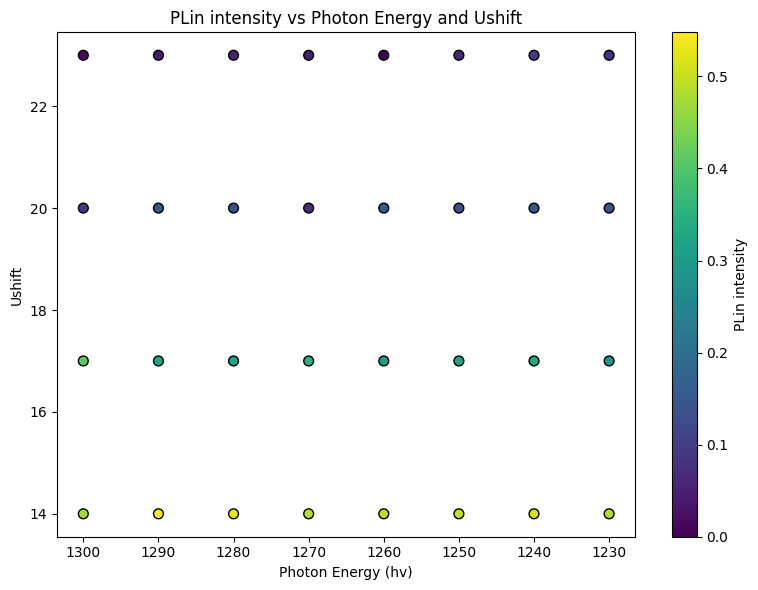

In [423]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))

sc = ax.scatter(
    complete["Photon Energy"],          # x-axis
    complete["Ushift"],      # y-axis
    c=complete["PLin"],     # color = PL intensity
    cmap="viridis",    # choose any colormap
    s=50,              # marker size
    edgecolor="k"      # optional, black edge for clarity
)

ax.set_xlabel("Photon Energy (hv)")
ax.set_ylabel("Ushift")
ax.set_title("PLin intensity vs Photon Energy and Ushift")
ax.invert_xaxis()  # common in spectroscopy

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("PLin intensity")
plt.tight_layout()
plt.show()

